# Modeling Data Comparison

Compare all five versions of the computational model fit (Q/H-values) available locally.
Goal: understand what changed between fitting rounds and validate the new Q5_Hpretest initialisation.

See vault note *Behavioral Modeling / Modeling data.md* for full version history and open questions.

Data loaded directly from per-subject CSVs (no behavioural `.mat` files required).

In [1]:
import os
import sys
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

sys.path.append('../')
from utils.data import load_subject_lut

In [2]:
BASE_DIR = '/Users/hugofluhr/phd_local/data/LearningHabits/dev_sample'
MODELING_DATA_DIR = os.path.join(BASE_DIR, 'modeling_data')

# LUT: raw CSV id (lowercase, e.g. 'h04b9k') → 'sub-04'
_lut = load_subject_lut(BASE_DIR)                          # {'sub-04': 'H04B9K', ...}
ID_TO_SUB = {v.lower(): k for k, v in _lut.items()}       # {'h04b9k': 'sub-04', ...}

VERSIONS = {
    '2024-09-27':       {'suffix': 'compmodel2709',          'param_n': '20', 'status': 'baseline — used for SNE 2024 and original GLMs'},
    '2025-12-18':       {'suffix': 'compmodel251218',         'param_n': '5',  'status': 'DO NOT USE — αck=0 artefact in ~20 subjects'},
    '2026-02-06':       {'suffix': 'compmodel260206',         'param_n': '5',  'status': 'corrected re-fit; used for all manuscript GLMs'},
    'Q1':               {'suffix': 'compmodelq1',             'param_n': '5',  'status': 'undocumented — RL_CK2, Q1 init (meaning unclear)'},
    '2026-05-reduced':  {'suffix': 'compmodel052026reduced',  'param_n': '5',  'status': 'new — RL_CK2, Q5_Hpretest init'},
    '2026-05-combined': {'suffix': 'compmodel052026combined', 'param_n': '6',  'status': 'new — RL_CK3/omega, Q5_Hpretest init', 'has_omega': True},
}

# sub-04 (H04B9K) and sub-45 (K11L3L): αck=0 in all versions
EXCLUDED_SUBJECTS = ['sub-04', 'sub-45']

RL_COLS = [f'stim{i}_value_rl' for i in range(1, 9)]
CK_COLS = [f'stim{i}_value_ck' for i in range(1, 9)]


def load_version(version_name):
    """Load all per-subject CSVs for a version into a single DataFrame.
    Adds subject_id (sub-XX format), session_type, and a stable row_idx per
    (subject, session_type) used for cross-version merging.
    """
    cfg = VERSIONS[version_name]
    version_dir = os.path.join(MODELING_DATA_DIR, version_name)
    files = sorted(glob.glob(os.path.join(version_dir, f'*_{cfg["suffix"]}.csv')))
    dfs = []
    for f in files:
        df = pd.read_csv(f)
        fname = os.path.basename(f)
        session_type = 'learning' if 'learning' in fname else 'test'
        # map raw id → sub-XX
        df['ID'] = df['ID'].str.lower().map(ID_TO_SUB).fillna(df['ID'].str.lower())
        df.rename(columns={'ID': 'subject_id'}, inplace=True)
        df['session_type'] = session_type
        # stable sort so row_idx aligns across versions
        sort_cols = ['run', 'trial'] if 'run' in df.columns else ['trial']
        df = df.sort_values(['subject_id'] + sort_cols).reset_index(drop=True)
        df['row_idx'] = df.groupby('subject_id').cumcount()
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)


data = {v: load_version(v) for v in VERSIONS}
print('Loaded:', list(data.keys()))

Loaded: ['2024-09-27', '2025-12-18', '2026-02-06', 'Q1', '2026-05-reduced', '2026-05-combined']


## 1. Data inventory

In [3]:
rows = []
for version, df in data.items():
    cfg = VERSIONS[version]
    n = cfg['param_n']
    param_str = f'alpha_rl{n}, beta_rl{n}, alpha_ck{n}, beta_ck{n}'
    if cfg.get('has_omega'):
        param_str += f', omega{n}'
    rows.append({
        'version': version,
        'n_subjects': df['subject_id'].nunique(),
        'n_rows': len(df),
        'param_cols': param_str,
        'status': cfg['status'],
    })

pd.DataFrame(rows).set_index('version')

,n_subjects,n_rows,param_cols,status
version,,,,
2024-09-27,67,21592,"alpha_rl20, beta_rl20, alpha_ck20, beta_ck20",baseline — used for SNE 2024 and original GLMs
2025-12-18,67,21592,"alpha_rl5, beta_rl5, alpha_ck5, beta_ck5",DO NOT USE — αck=0 artefact in ~20 subjects
2026-02-06,67,21592,"alpha_rl5, beta_rl5, alpha_ck5, beta_ck5",corrected re-fit; used for all manuscript GLMs
Q1,67,21592,"alpha_rl5, beta_rl5, alpha_ck5, beta_ck5","undocumented — RL_CK2, Q1 init (meaning unclear)"
2026-05-reduced,67,21592,"alpha_rl5, beta_rl5, alpha_ck5, beta_ck5","new — RL_CK2, Q5_Hpretest init"
2026-05-combined,67,21592,"alpha_rl6, beta_rl6, alpha_ck6, beta_ck6, omega6","new — RL_CK3/omega, Q5_Hpretest init"


## 2. Quality check — 2025-12-18 αck=0 artefact

The December 2025 re-fit had a bug that left ~20 subjects with αck=0 (no CK learning).
The February 2026 correction fixed this; only the two structurally-excluded subjects
(sub-04, sub-45) retain αck=0 across all versions.

In [4]:
rows = []
for version, df in data.items():
    n = VERSIONS[version]['param_n']
    col = f'alpha_ck{n}'
    params = df.groupby('subject_id')[col].first()
    zero_subs = sorted(params[params == 0].index.tolist())
    rows.append({
        'version': version,
        'n_αck=0': len(zero_subs),
        'subjects': zero_subs,
    })

pd.DataFrame(rows).set_index('version')

,n_αck=0,subjects
version,,
2024-09-27,2,"[sub-04, sub-45]"
2025-12-18,21,"[sub-02, sub-03, sub-04, sub-07, sub-14, sub-1..."
2026-02-06,2,"[sub-04, sub-45]"
Q1,0,[]
2026-05-reduced,0,[]
2026-05-combined,1,[sub-04]


## 3. Pairwise Q/H value comparisons

Baseline is **2024-09-27**. Four comparisons:
- **2024 vs 2026-02-06** — sanity check; should be near-identical (r ≈ 1)
- **2024 vs 2026-05-reduced** — effect of Q5_Hpretest init on Q-values; large H-value divergence expected
- **2024 vs 2026-05-combined** — same init + extended model class (RL_CK3/omega)
- **2026-05-reduced vs 2026-05-combined** — difference between the two new models

Per-subject Pearson r is computed by pooling all 8 stimulus-value columns and all trials.

In [5]:
MERGE_COLS = ['subject_id', 'session_type', 'row_idx']


def per_subject_corr(df_ref, df_new, value_cols):
    """Pearson r per subject between two versions, pooled across stimuli and trials."""
    merged = (
        df_ref[MERGE_COLS + value_cols]
        .merge(df_new[MERGE_COLS + value_cols], on=MERGE_COLS, suffixes=('_ref', '_new'))
    )
    results = []
    for sub_id, grp in merged.groupby('subject_id'):
        ref = grp[[f'{c}_ref' for c in value_cols]].values.flatten()
        new = grp[[f'{c}_new' for c in value_cols]].values.flatten()
        mask = ~(np.isnan(ref) | np.isnan(new))
        if mask.sum() < 2 or np.std(ref[mask]) == 0 or np.std(new[mask]) == 0:
            r = np.nan
        else:
            r, _ = stats.pearsonr(ref[mask], new[mask])
        results.append({'subject_id': sub_id, 'r': r})
    return pd.DataFrame(results)

In [6]:
COMPARISONS = [
    ('2024-09-27',      '2026-02-06',       '2024 vs 2026-02-06'),
    ('2024-09-27',      'Q1',               '2024 vs Q1'),
    ('2024-09-27',      '2026-05-reduced',  '2024 vs reduced'),
    ('2024-09-27',      '2026-05-combined', '2024 vs combined'),
    ('2026-05-reduced', '2026-05-combined', 'reduced vs combined'),
]

corr_rl, corr_ck = {}, {}
for ref_v, new_v, label in COMPARISONS:
    corr_rl[label] = per_subject_corr(data[ref_v], data[new_v], RL_COLS)
    corr_ck[label] = per_subject_corr(data[ref_v], data[new_v], CK_COLS)

header = f"{'Comparison':<30}  {'Q median r':>12}  {'H median r':>12}"
print(header)
print('-' * len(header))
for _, _, label in COMPARISONS:
    q_med = corr_rl[label]['r'].median()
    h_med = corr_ck[label]['r'].median()
    print(f'{label:<30}  {q_med:>12.4f}  {h_med:>12.4f}')

Comparison                        Q median r    H median r
----------------------------------------------------------
2024 vs 2026-02-06                    1.0000        1.0000
2024 vs Q1                            0.9990        0.7770
2024 vs reduced                       0.9994        0.6251
2024 vs combined                      0.9999        0.5962
reduced vs combined                   0.9999        0.9203


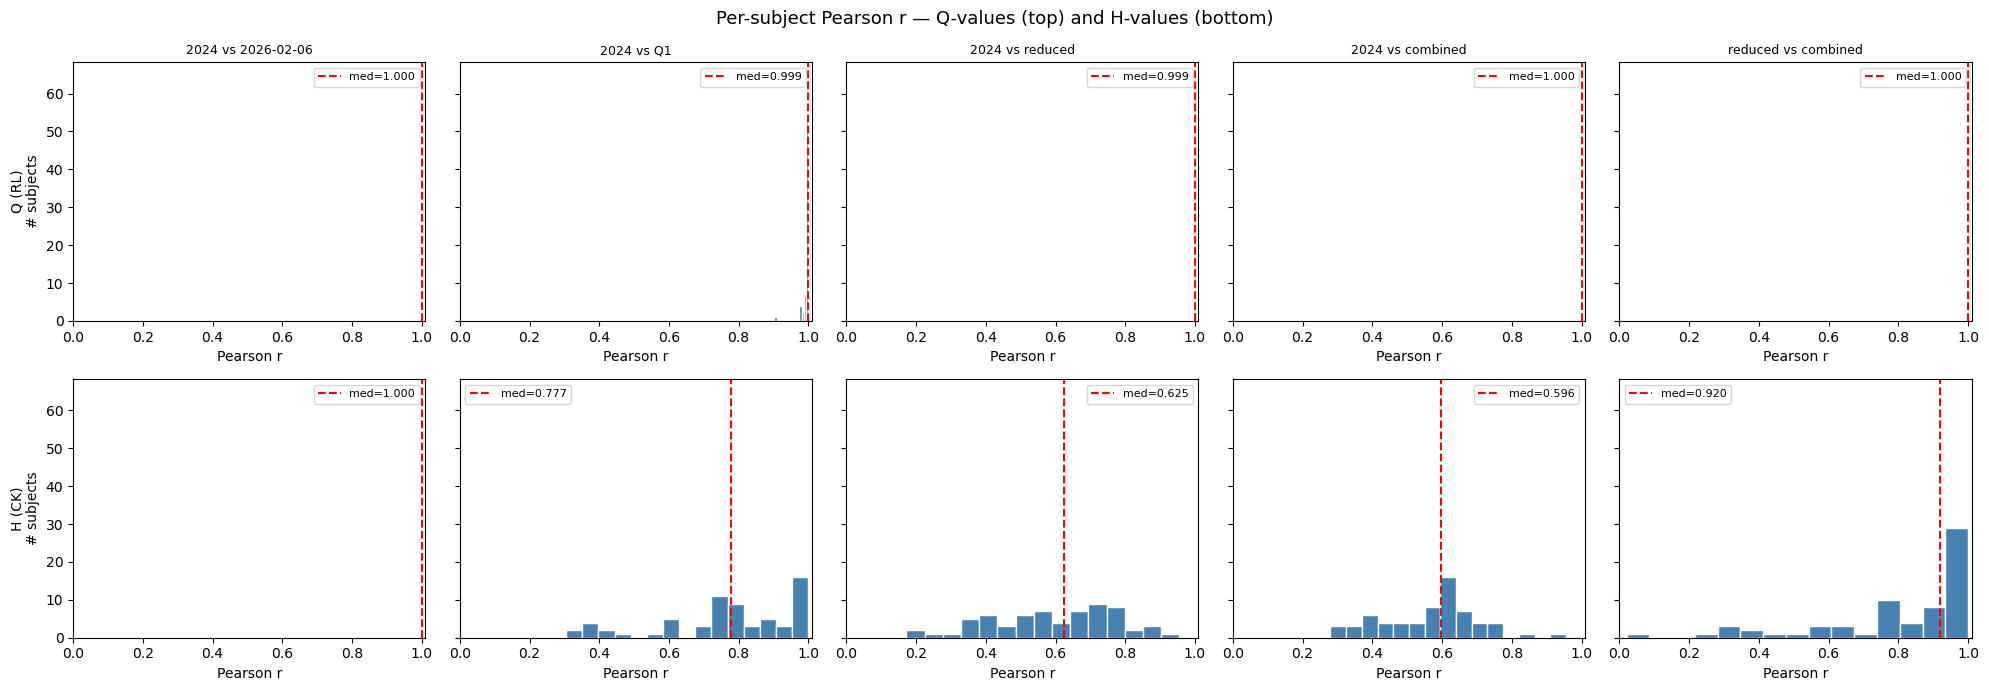

In [7]:
n_comp = len(COMPARISONS)
fig, axes = plt.subplots(2, n_comp, figsize=(4 * n_comp, 7), sharey=True)
fig.suptitle('Per-subject Pearson r — Q-values (top) and H-values (bottom)', fontsize=13)

for col_idx, (_, _, label) in enumerate(COMPARISONS):
    for row_idx, (corr_dict, row_label) in enumerate([(corr_rl, 'Q (RL)'), (corr_ck, 'H (CK)')]):
        ax = axes[row_idx, col_idx]
        r_vals = corr_dict[label]['r'].dropna()
        ax.hist(r_vals, bins=15, edgecolor='white', color='steelblue')
        med = r_vals.median()
        ax.axvline(med, color='red', linestyle='--', label=f'med={med:.3f}')
        if row_idx == 0:
            ax.set_title(label, fontsize=9)
        ax.set_xlabel('Pearson r')
        ax.set_xlim([0, 1.01])
        ax.legend(fontsize=8)
        if col_idx == 0:
            ax.set_ylabel(f'{row_label}\n# subjects')

plt.tight_layout()
plt.show()

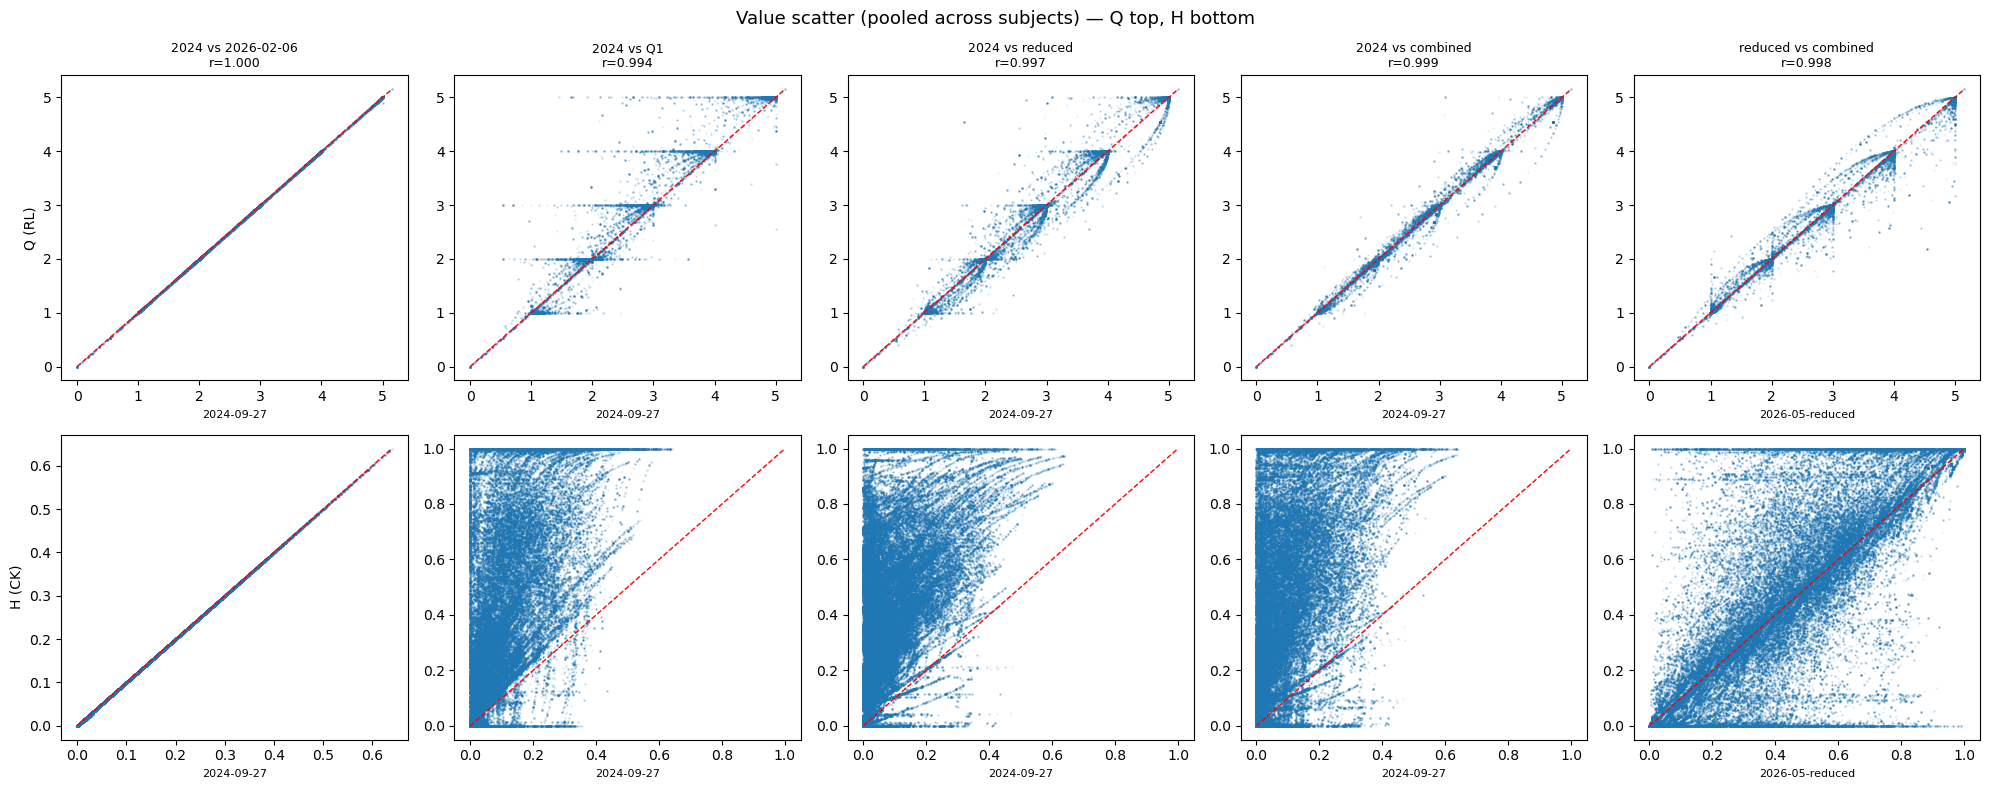

In [8]:
fig, axes = plt.subplots(2, n_comp, figsize=(4 * n_comp, 8))
fig.suptitle('Value scatter (pooled across subjects) — Q top, H bottom', fontsize=13)

for col_idx, (ref_v, new_v, label) in enumerate(COMPARISONS):
    for row_idx, (cols, row_label) in enumerate([(RL_COLS, 'Q (RL)'), (CK_COLS, 'H (CK)')]):
        ax = axes[row_idx, col_idx]
        merged = (
            data[ref_v][MERGE_COLS + cols]
            .merge(data[new_v][MERGE_COLS + cols], on=MERGE_COLS, suffixes=('_ref', '_new'))
        )
        ref_all = merged[[f'{c}_ref' for c in cols]].values.flatten()
        new_all = merged[[f'{c}_new' for c in cols]].values.flatten()
        mask = ~(np.isnan(ref_all) | np.isnan(new_all))
        r, _ = stats.pearsonr(ref_all[mask], new_all[mask])

        ax.scatter(ref_all[mask], new_all[mask], s=0.5, alpha=0.1, rasterized=True)
        lims = [min(ref_all[mask].min(), new_all[mask].min()),
                max(ref_all[mask].max(), new_all[mask].max())]
        ax.plot(lims, lims, 'r--', linewidth=1)
        if row_idx == 0:
            ax.set_title(f'{label}\nr={r:.3f}', fontsize=9)
        ax.set_xlabel(ref_v, fontsize=8)
        if col_idx == 0:
            ax.set_ylabel(row_label)

plt.tight_layout()
plt.show()

## 4. Temporal evolution

Mean ± SEM Q and H values per stimulus across trials, for the three usable versions:
**2024-09-27**, **2026-05-reduced**, **2026-05-combined**.

The dashed vertical line marks the learning/test session boundary.
The key expected difference: H-values in the 2026-05 versions should start non-zero
(initialised from practice-session choices rather than zeros).

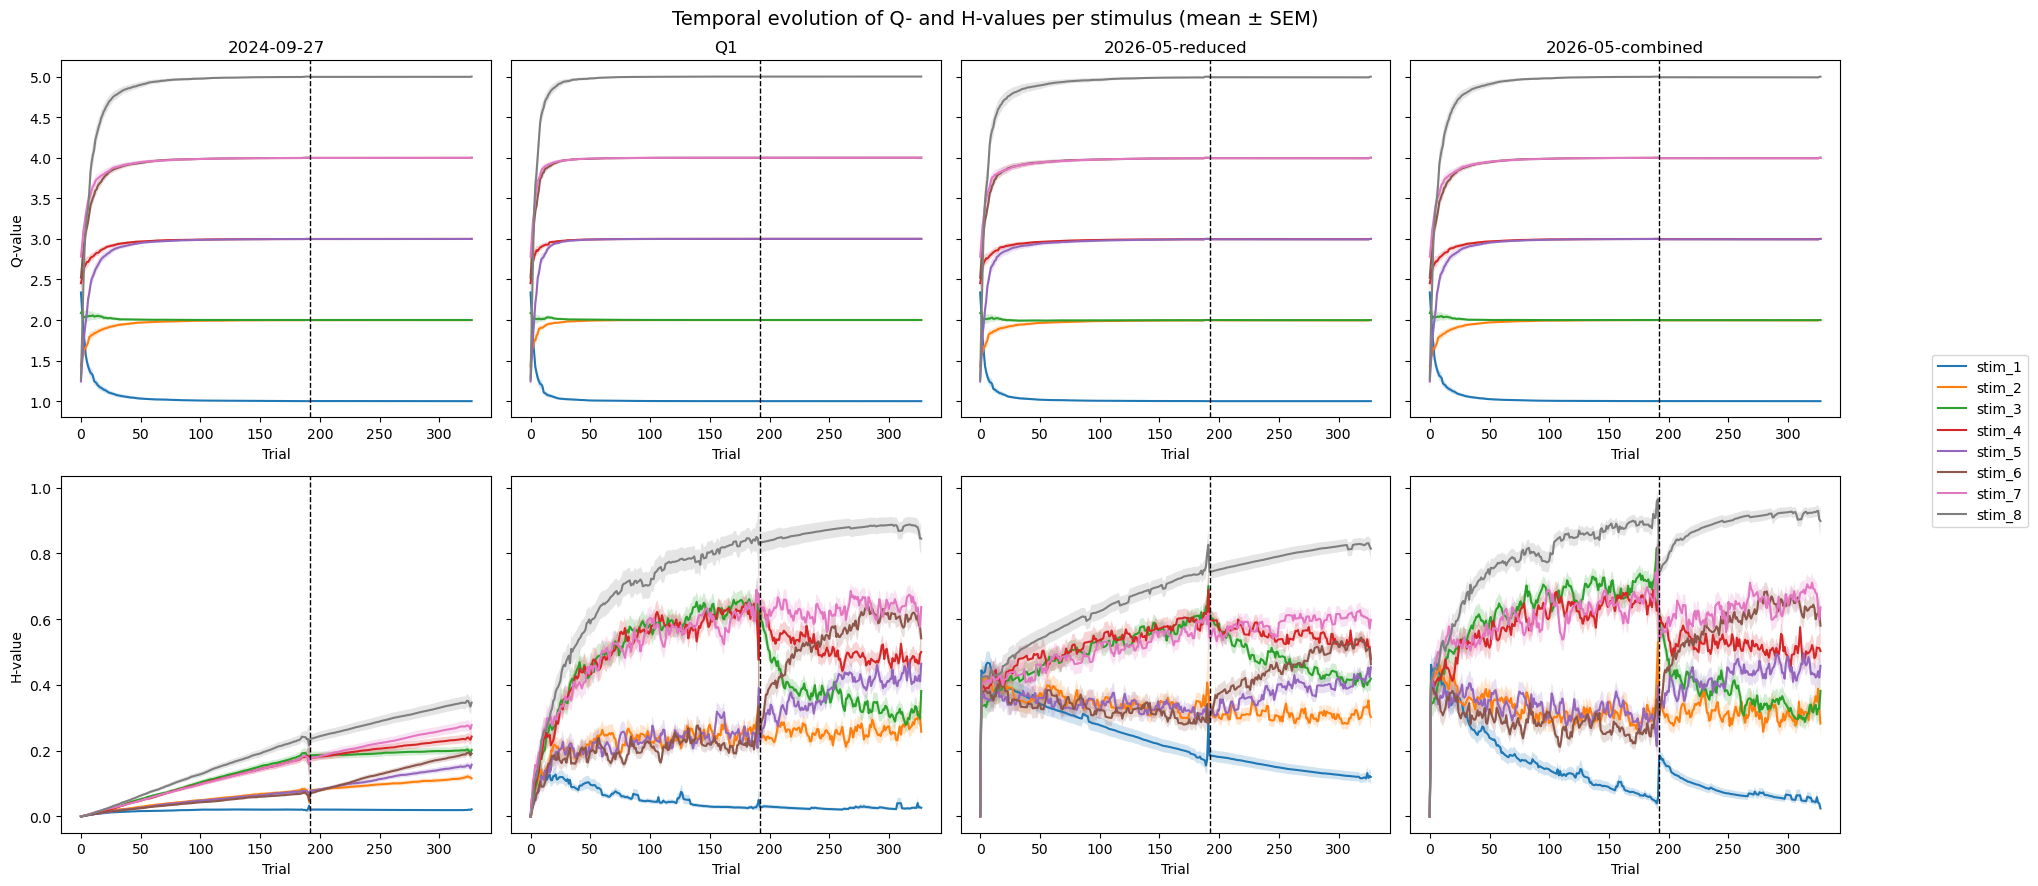

In [9]:
PLOT_VERSIONS = ['2024-09-27', 'Q1', '2026-05-reduced', '2026-05-combined']
STIM_LABELS = [f'stim_{i}' for i in range(1, 9)]


def build_temporal_arrays(df, stim_cols, excluded=EXCLUDED_SUBJECTS):
    df = df[~df['subject_id'].isin(excluded)].copy()
    max_lrn = int(df[df['session_type'] == 'learning']['row_idx'].max()) + 1
    df['global_t'] = np.where(
        df['session_type'] == 'learning', df['row_idx'], df['row_idx'] + max_lrn)
    subjects = sorted(df['subject_id'].unique())
    n_trials = int(df['global_t'].max()) + 1
    arr = np.full((len(subjects), n_trials, len(stim_cols)), np.nan)
    for i, sub in enumerate(subjects):
        sub_df = df[df['subject_id'] == sub]
        t_idx = sub_df['global_t'].values.astype(int)
        for j, col in enumerate(stim_cols):
            arr[i, t_idx, j] = sub_df[col].values
    return arr, max_lrn


n_plot = len(PLOT_VERSIONS)
fig, axs = plt.subplots(2, n_plot, figsize=(5 * n_plot, 9), sharey='row')
fig.suptitle('Temporal evolution of Q- and H-values per stimulus (mean ± SEM)', fontsize=14)

for col_idx, version in enumerate(PLOT_VERSIONS):
    q_arr, boundary = build_temporal_arrays(data[version], RL_COLS)
    h_arr, _ = build_temporal_arrays(data[version], CK_COLS)

    for row_idx, (arr, ylabel) in enumerate([(q_arr, 'Q-value'), (h_arr, 'H-value')]):
        ax = axs[row_idx, col_idx]
        t = np.arange(arr.shape[1])
        for s_idx in range(arr.shape[2]):
            mean = np.nanmean(arr[:, :, s_idx], axis=0)
            n_valid = (~np.isnan(arr[:, :, s_idx])).sum(axis=0)
            sem = np.nanstd(arr[:, :, s_idx], axis=0, ddof=1) / np.sqrt(np.maximum(n_valid, 1))
            ax.plot(t, mean, label=STIM_LABELS[s_idx])
            ax.fill_between(t, mean - sem, mean + sem, alpha=0.2)
        ax.axvline(x=boundary, color='black', linestyle='--', linewidth=1)
        ax.set_xlabel('Trial')
        if col_idx == 0:
            ax.set_ylabel(ylabel)
        if row_idx == 0:
            ax.set_title(version)

handles, labels_leg = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels_leg, loc='center right', bbox_to_anchor=(1.02, 0.5))
plt.tight_layout(rect=[0, 0, 0.93, 1])
plt.show()

## 5. Model parameters

Compare fitted RL and CK learning rates across the four usable versions.
Excluded subjects (sub-04, sub-45) removed.
For **2026-05-combined** only: the additional **omega** parameter (meaning TBD — see open questions).

In [10]:
USABLE_VERSIONS = ['2024-09-27', '2026-02-06', 'Q1', '2026-05-reduced', '2026-05-combined']


def get_params(version_name):
    df = data[version_name]
    n = VERSIONS[version_name]['param_n']
    raw_cols = [f'alpha_rl{n}', f'beta_rl{n}', f'alpha_ck{n}', f'beta_ck{n}']
    rename = {f'alpha_rl{n}': 'alpha_rl', f'beta_rl{n}': 'beta_rl',
              f'alpha_ck{n}': 'alpha_ck', f'beta_ck{n}': 'beta_ck'}
    if VERSIONS[version_name].get('has_omega'):
        raw_cols.append(f'omega{n}')
        rename[f'omega{n}'] = 'omega'
    params = df.groupby('subject_id')[raw_cols].first().reset_index()
    params.rename(columns=rename, inplace=True)
    params['version'] = version_name
    return params


params_df = pd.concat([get_params(v) for v in USABLE_VERSIONS], ignore_index=True)
params_df = params_df[~params_df['subject_id'].isin(EXCLUDED_SUBJECTS)]
params_df.groupby('version')[['alpha_rl', 'beta_rl', 'alpha_ck', 'beta_ck']].describe().round(4)

alpha_rl                                                  \
                    count    mean     std     min     25%     50%     75%   
version                                                                     
2024-09-27           65.0  0.5790  0.3079  0.0669  0.3040  0.5322  0.8637   
2026-02-06           65.0  0.5786  0.3075  0.0669  0.3038  0.5323  0.8638   
2026-05-combined     65.0  0.6241  0.3166  0.0735  0.3446  0.6507  0.9612   
2026-05-reduced      65.0  0.7165  0.3066  0.0436  0.4961  0.8161  1.0000   
Q1                   65.0  0.7959  0.2510  0.1147  0.6283  0.9025  1.0000   

                      beta_rl          ... alpha_ck         beta_ck          \
                  max   count    mean  ...      75%     max   count    mean   
version                                ...                                    
2024-09-27        1.0    65.0  2.2426  ...   0.0089  0.0139    65.0  7.7574   
2026-02-06        1.0    65.0  2.2428  ...   0.0089  0.0139    65.0  7.7572   
2026-05-combined  1.0    65.0  2.3266  ...   0.3835  1.0000    65.0  1.5113   
2026-05-reduced   1.0    65.0  3.5843  ...   0.0347  1.0000    65.0  6.4157   
Q1                1.0    65.0  7.9753  ...   0.2372  1.0000    65.0  2.0247   

                                                                  
                     std     min     25%     50%     75%     max  
version                                                           
2024-09-27        0.7404  5.7559  7.2164  7.8028  8.3354  9.0672  
2026-02-06        0.7406  5.7559  7.2165  7.8026  8.3358  9.0672  
2026-05-combined  1.3820  0.0000  0.6846  1.3392  1.7138  7.9257  
2026-05-reduced   1.1337  3.7610  5.8145  6.5565  7.1412  9.0581  
Q1                1.6056  0.3473  0.9390  1.5749  2.1669  6.7192  

[5 rows x 32 columns]

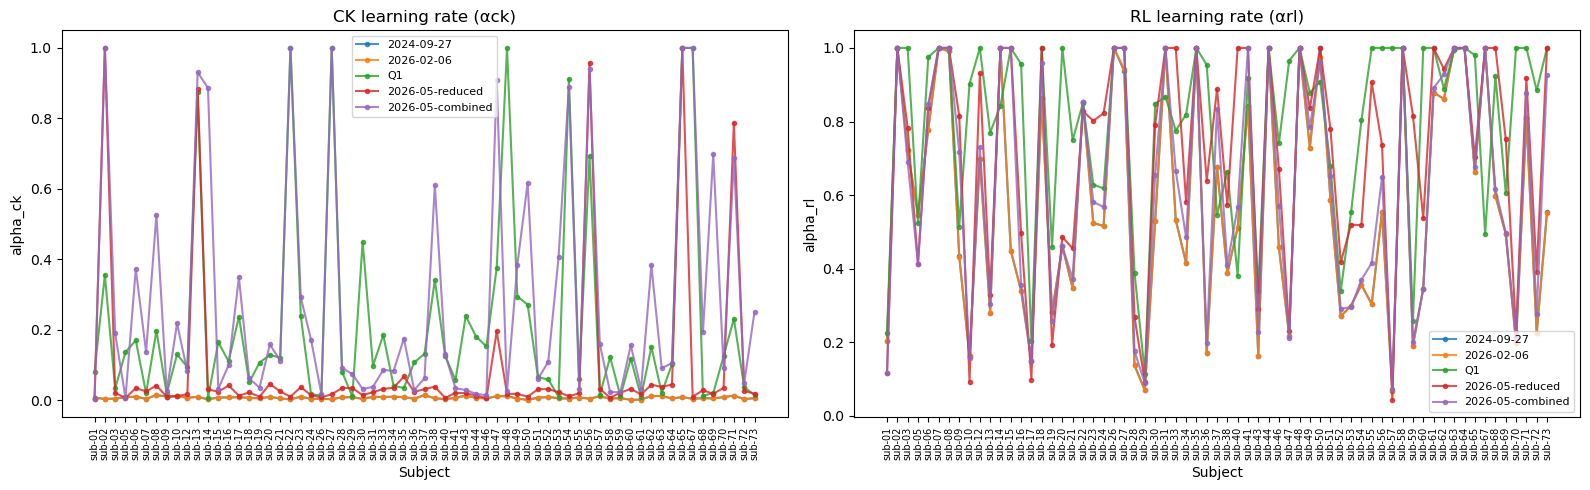

In [11]:
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, param, title in [
    (axes[0], 'alpha_ck', 'CK learning rate (αck)'),
    (axes[1], 'alpha_rl', 'RL learning rate (αrl)'),
]:
    for i, version in enumerate(USABLE_VERSIONS):
        vdf = params_df[params_df['version'] == version].sort_values('subject_id')
        ax.plot(vdf['subject_id'], vdf[param], marker='o', linestyle='-',
                label=version, color=colors[i], alpha=0.8, markersize=3)
    ax.set_title(title)
    ax.set_xlabel('Subject')
    ax.set_ylabel(param)
    ax.tick_params(axis='x', rotation=90, labelsize=7)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

count    65.0000
mean      0.6409
std       0.1771
min       0.2074
25%       0.5435
50%       0.6416
75%       0.7509
max       1.0000
Name: omega, dtype: float64


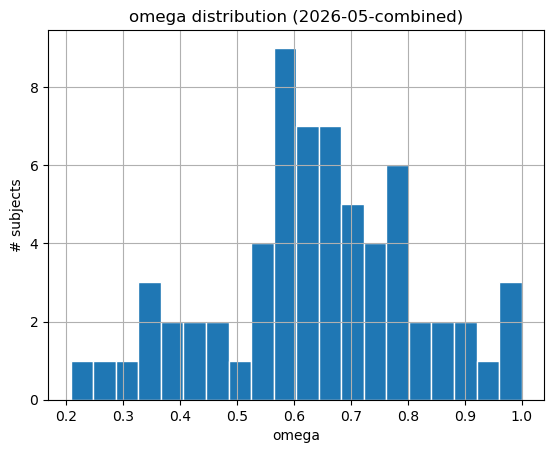

In [12]:
# omega parameter — 2026-05-combined only
omega_df = params_df[params_df['version'] == '2026-05-combined'][['subject_id', 'omega']].dropna()
print(omega_df['omega'].describe().round(4))
omega_df['omega'].hist(bins=20, edgecolor='white')
plt.title('omega distribution (2026-05-combined)')
plt.xlabel('omega')
plt.ylabel('# subjects')
plt.show()

## Open questions

- [ ] What does **Q5** mean exactly — Q-values initialised to 5? Confirm with Stephan.
- [ ] What is `data_RP_MRI_model_RL_CK_reduced_Q1.RData`? Where did it come from, has it ever been exported or used?
- [ ] What changed between 2024-09-27 and 2026-02-06 — why was the model re-fit in the first place?
- [ ] What does the **omega** parameter in RL_CK3 (2026-05-combined) represent?
- [ ] Does **reduced** still outperform **combined** in model fit with Q5_Hpretest initialisation, or does that comparison need to be re-run?
- [ ] The 2026-02-06 version is described as "essentially identical" to 2024-09-27 — confirmed quantitatively in section 3 above.